# Step 2 — Obtain & Inspect the Public EEG Dataset

**Dataset:** BNCI2014-008 (P300 Speller, first choice for pipeline development)  
**Source:** MOABB (Mother of All BCI Benchmarks)  
**Goal:** Download, inspect metadata, plot raw EEG, verify units, and check event counts.

## 0. Install Dependencies

In [1]:
# Run once if packages are missing
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])

for pkg in ["moabb", "mne", "matplotlib", "numpy"]:
    install(pkg)

print("All dependencies ready.")


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


All dependencies ready.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## 1. Download Dataset via MOABB

MOABB handles caching automatically — the first run downloads to `~/mne_data/`.  
Subsequent runs load from cache.

In [2]:
import moabb
from moabb.datasets import BNCI2014_008
import mne
import numpy as np
import matplotlib
matplotlib.use("Agg")  # non-interactive backend; change to 'TkAgg' or remove for Jupyter inline
import matplotlib.pyplot as plt
from datetime import date

moabb.set_log_level("WARNING")  # suppress verbose MOABB logs
mne.set_log_level("WARNING")

dataset = BNCI2014_008()

print("=" * 50)
print("DATASET DOWNLOAD RECORD")
print("=" * 50)
print(f"Dataset name    : BNCI2014-008")
print(f"Source          : MOABB (moabb.datasets.BNCI2014_008)")
print(f"Download date   : {date.today()}")
print(f"MOABB version   : {moabb.__version__}")
print(f"MNE version     : {mne.__version__}")

/Users/ziadelsisi/.local/share/virtualenvs/eeg-p300-recognition-assessment-gan_qdjr/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DATASET DOWNLOAD RECORD
Dataset name    : BNCI2014-008
Source          : MOABB (moabb.datasets.BNCI2014_008)
Download date   : 2026-09-25
MOABB version   : 1.7.2
MNE version     : 1.13.2


## 2. Inspect Metadata

Print number of subjects, channels, sampling rate, events, trial counts, and channel names.

In [3]:
# ── Load one subject to inspect structure ──────────────────────────────────────
subject_id = dataset.subject_list[0]  # typically subject 1
sessions   = dataset.get_data(subjects=[subject_id])

# Navigate the nested dict: {subject: {session: {run: raw}}}
session_key = list(sessions[subject_id].keys())[0]
run_key     = list(sessions[subject_id][session_key].keys())[0]
raw         = sessions[subject_id][session_key][run_key]

info = raw.info

print("=" * 50)
print("METADATA SUMMARY  (Section 4 Fill-in)")
print("=" * 50)
print(f"Number of subjects  : {len(dataset.subject_list)}  → {dataset.subject_list}")
print(f"Number of channels  : {info['nchan']}")
print(f"Sampling rate       : {info['sfreq']} Hz")
print(f"Channel names       : {info['ch_names']}")
print(f"Session key used    : '{session_key}'")
print(f"Run key used        : '{run_key}'")
print(f"Recording duration  : {raw.times[-1]:.1f} s")

This is nemar-py 0.3.0.
Preparing to download nm000169 from https://data.nemar.org/
Retrieving 5 of 110 manifest files (16 concurrent downloads).
primary backend failed; falling back to next layer: 'README.md' is not annexed (no sha256/md5 checksum on the manifest entry); the S3 backend has nothing to fetch.


Overall:  50%|█████     | 5.00k/9.96k [00:01<00:01, 2.96kB/s]


Finished downloading nm000169 v1.0.2.
This is nemar-py 0.3.0.
Preparing to download nm000169 from https://data.nemar.org/
Retrieving 5 of 110 manifest files (16 concurrent downloads).


S3: 100%|██████████| 20.6M/20.6M [01:06<00:00, 325kB/s] 
/Users/ziadelsisi/.local/share/virtualenvs/eeg-p300-recognition-assessment-gan_qdjr/lib/python3.11/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")


Finished downloading nm000169 v1.0.2.
METADATA SUMMARY  (Section 4 Fill-in)
Number of subjects  : 8  → [1, 2, 3, 4, 5, 6, 7, 8]
Number of channels  : 10
Sampling rate       : 256.0 Hz
Channel names       : ['Fz', 'Cz', 'Pz', 'Oz', 'P3', 'P4', 'PO7', 'PO8', 'Target stim', 'Flash stim']
Session key used    : '0'
Run key used        : '0'
Recording duration  : 1358.2 s


In [4]:
# ── Count total subjects and sessions across the full dataset ───────────────────
print("\nAll subjects in dataset:", dataset.subject_list)
print("Number of sessions per subject:",
      {k: list(v.keys()) for k, v in sessions.items()})


All subjects in dataset: [1, 2, 3, 4, 5, 6, 7, 8]
Number of sessions per subject: {1: ['0']}


## 3. Plot Raw EEG (10–20 seconds)

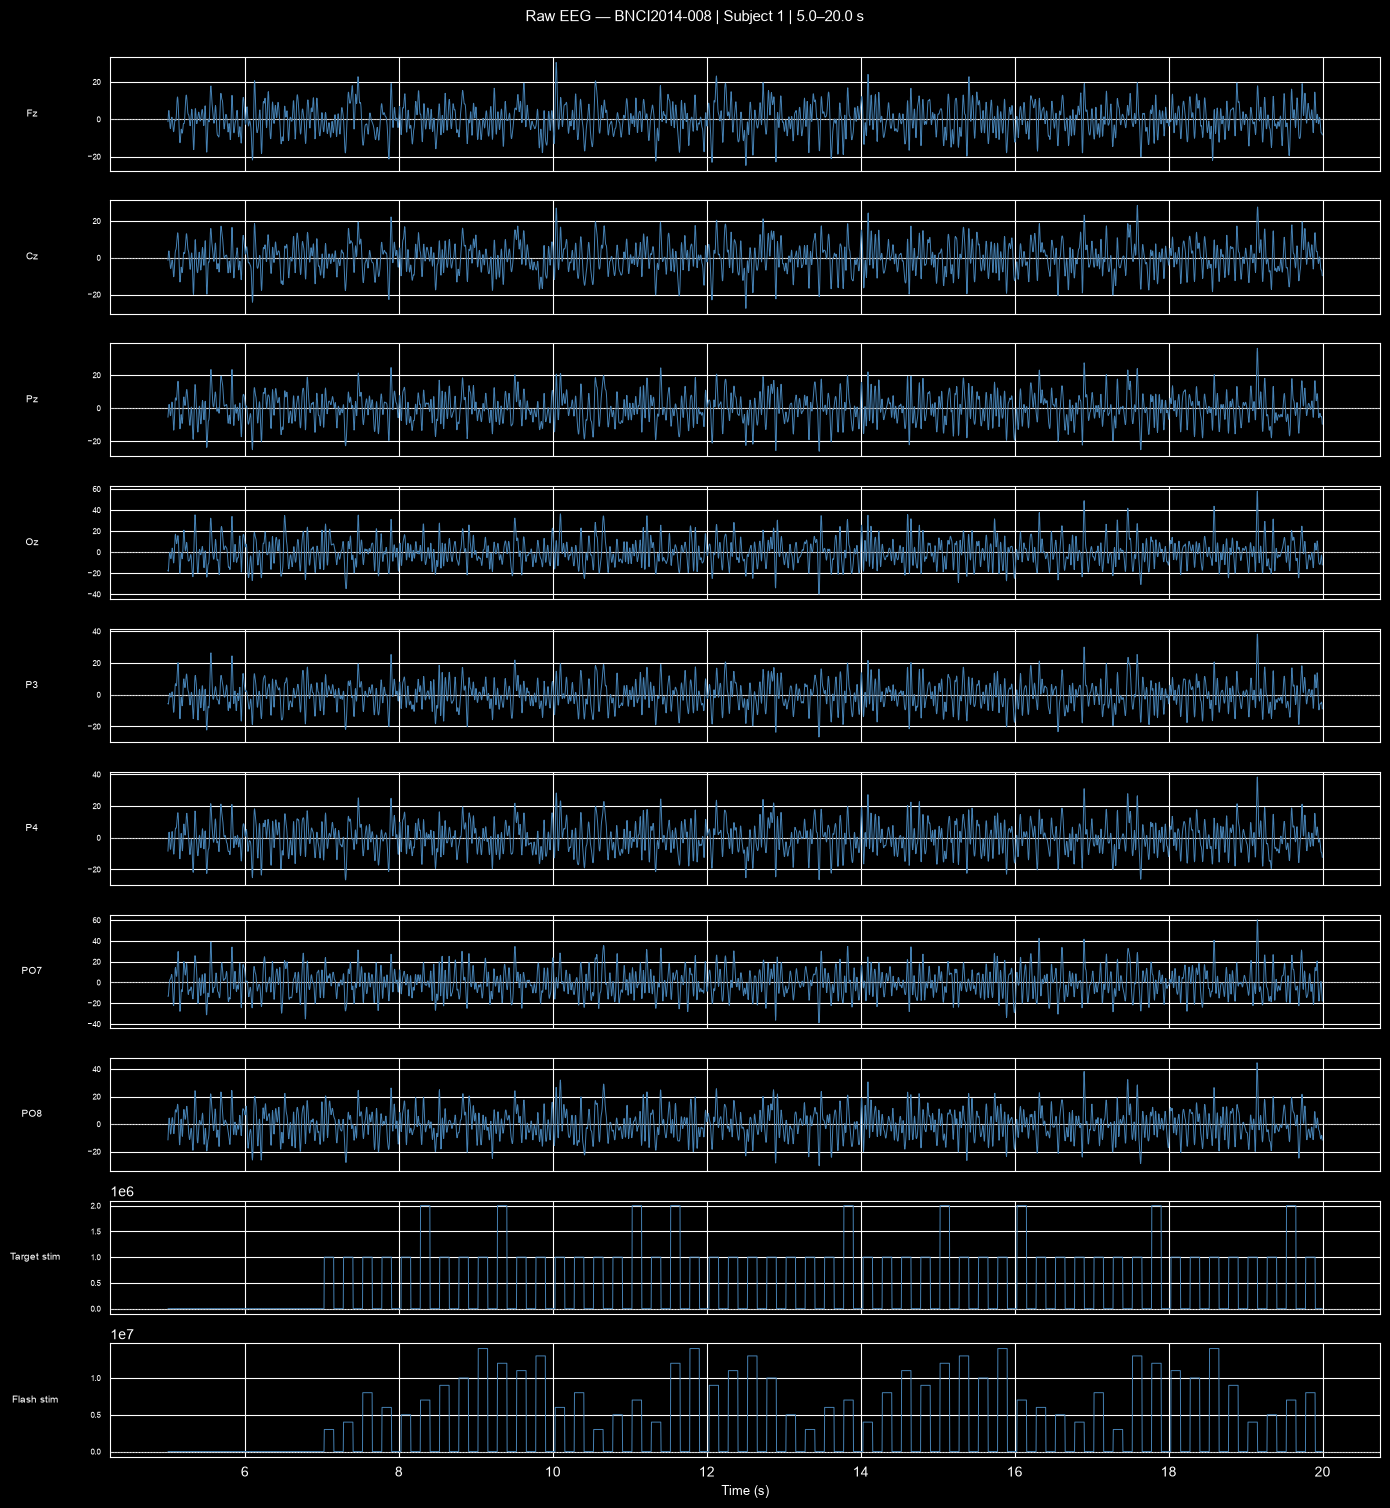

Figure saved → raw_eeg_plot.png


In [7]:
%matplotlib inline
# ── Extract 15-second window of raw data ──────────────────────────────────────
t_start, t_end = 5.0, 20.0  # seconds
sfreq  = info['sfreq']
s_start = int(t_start * sfreq)
s_end   = int(t_end   * sfreq)

data, times = raw[:, s_start:s_end]  # shape: (n_channels, n_samples)
times_plot  = times  # already in seconds relative to recording start

# ── Plot ──────────────────────────────────────────────────────────────────────
n_channels = data.shape[0]
fig, axes  = plt.subplots(n_channels, 1,
                           figsize=(14, 1.5 * n_channels),
                           sharex=True)

if n_channels == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.plot(times_plot, data[i] * 1e6, lw=0.7, color="steelblue")  # V → µV
    ax.set_ylabel(info['ch_names'][i], fontsize=7, rotation=0,
                  labelpad=40, va="center")
    ax.axhline(0, color="grey", lw=0.4, ls="--")
    ax.tick_params(axis="y", labelsize=6)

axes[-1].set_xlabel("Time (s)", fontsize=9)
fig.suptitle(
    f"Raw EEG — BNCI2014-008 | Subject {subject_id} | {t_start}–{t_end} s",
    fontsize=11, y=1.002
)
plt.tight_layout()
fig.savefig("raw_eeg_plot.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved → raw_eeg_plot.png")

## 4. Check Units

MOABB/MNE loads EEG in **Volts (V)** internally. We scale to µV only for display.

In [8]:
# ── Unit check ────────────────────────────────────────────────────────────────
sample_value_V  = data[0, 100]           # raw value from MNE (Volts)
sample_value_uV = sample_value_V * 1e6  # converted to µV

print("=" * 50)
print("UNIT HANDLING RECORD")
print("=" * 50)
print(f"MNE internal unit       : Volts (V)")
print(f"Sample raw value        : {sample_value_V:.6e} V")
print(f"Same value in µV        : {sample_value_uV:.4f} µV")
print()
print("Conclusion: MNE stores data in Volts. Multiply by 1e6 for µV display.")
print("No automatic scaling is applied by MNE — conversion must be done manually.")

# Verify MNE channel types
eeg_channels = [(ch, raw.get_channel_types()[i])
                for i, ch in enumerate(info['ch_names'])]
print(f"\nChannel types: {set(t for _, t in eeg_channels)}")

UNIT HANDLING RECORD
MNE internal unit       : Volts (V)
Sample raw value        : 2.107848e-06 V
Same value in µV        : 2.1078 µV

Conclusion: MNE stores data in Volts. Multiply by 1e6 for µV display.
No automatic scaling is applied by MNE — conversion must be done manually.

Channel types: {'stim', 'eeg'}


## 5. Check Events — Target vs NonTarget Counts

In [9]:
# ── Extract events from annotations ───────────────────────────────────────────
events, event_id = mne.events_from_annotations(raw)

print("=" * 50)
print("EVENT SUMMARY")
print("=" * 50)
print(f"Event ID mapping: {event_id}")
print()

# BNCI2014-008 uses event IDs: 1 = NonTarget, 2 = Target
# (MOABB maps 'Target' and 'NonTarget' annotations to integers)
for label, code in sorted(event_id.items(), key=lambda x: x[1]):
    count = int((events[:, 2] == code).sum())
    print(f"  Event '{label}' (ID={code}) : {count} trials")

# Identify Target and NonTarget robustly
target_label     = [k for k in event_id if "arget" in k and "Non" not in k]
nontarget_label  = [k for k in event_id if "on" in k.lower() and "arget" in k]

if target_label and nontarget_label:
    n_target    = int((events[:, 2] == event_id[target_label[0]]).sum())
    n_nontarget = int((events[:, 2] == event_id[nontarget_label[0]]).sum())
    ratio       = n_nontarget / n_target if n_target > 0 else float('inf')

    print()
    print("=" * 50)
    print("SECTION 4 FILL-IN — TARGET vs NONTARGET")
    print("=" * 50)
    print(f"Target trials    : {n_target}")
    print(f"NonTarget trials : {n_nontarget}")
    print(f"Class ratio      : 1 Target : {ratio:.1f} NonTarget  (expected ~1:5 for P300)")
else:
    print("\n[Note] Could not auto-identify Target/NonTarget — check event_id labels above.")

EVENT SUMMARY
Event ID mapping: {'NonTarget': 1, 'Target': 2}

  Event 'NonTarget' (ID=1) : 3500 trials
  Event 'Target' (ID=2) : 700 trials

SECTION 4 FILL-IN — TARGET vs NONTARGET
Target trials    : 700
NonTarget trials : 3500
Class ratio      : 1 Target : 5.0 NonTarget  (expected ~1:5 for P300)


## 6. Epoch Quick-Check (sanity)

Epoch around stimulus onset and confirm shape.

In [10]:
# ── Create epochs for a quick sanity check ────────────────────────────────────
tmin, tmax = -0.1, 0.8  # standard P300 window: -100 ms to +800 ms

epochs = mne.Epochs(
    raw, events, event_id=event_id,
    tmin=tmin, tmax=tmax,
    baseline=(tmin, 0),
    preload=True,
    verbose=False
)

print("=" * 50)
print("EPOCH SANITY CHECK")
print("=" * 50)
print(f"Epoch shape (n_epochs, n_channels, n_times) : {epochs.get_data().shape}")
print(f"Time window  : {tmin*1000:.0f} ms to {tmax*1000:.0f} ms")
print(f"Baseline     : {tmin*1000:.0f} ms to 0 ms")
print()
print(epochs)

EPOCH SANITY CHECK
Epoch shape (n_epochs, n_channels, n_times) : (4200, 10, 232)
Time window  : -100 ms to 800 ms
Baseline     : -100 ms to 0 ms

<Epochs | 4200 events (all good), -0.102 – 0.801 s (baseline -0.1 – 0 s), ~74.4 MiB, data loaded,
 'NonTarget': 3500
 'Target': 700>


## 7. Summary Table — Section 4 Fill-in

Collect all evidence in one place.

In [11]:
print("=" * 60)
print("SECTION 4 — COMPLETE FILL-IN")
print("=" * 60)

rows = [
    ("Dataset name",        "BNCI2014-008"),
    ("Source / version",    "MOABB (moabb.datasets.BNCI2014_008)"),
    ("Download date",       str(date.today())),
    ("Number of subjects",  str(len(dataset.subject_list))),
    ("Channel count",       str(info['nchan'])),
    ("Channel names",       ", ".join(info['ch_names'])),
    ("Sampling rate",       f"{info['sfreq']} Hz"),
    ("Data unit (MNE)",     "Volts (V) — multiply ×1e6 for µV display"),
    ("Event IDs",           str(event_id)),
]

for field, value in rows:
    print(f"  {field:<25} : {value}")

if target_label and nontarget_label:
    print(f"  {'Target trials':<25} : {n_target}")
    print(f"  {'NonTarget trials':<25} : {n_nontarget}")
    print(f"  {'Class ratio':<25} : 1 : {ratio:.1f}")

print("=" * 60)

SECTION 4 — COMPLETE FILL-IN
  Dataset name              : BNCI2014-008
  Source / version          : MOABB (moabb.datasets.BNCI2014_008)
  Download date             : 2026-09-25
  Number of subjects        : 8
  Channel count             : 10
  Channel names             : Fz, Cz, Pz, Oz, P3, P4, PO7, PO8, Target stim, Flash stim
  Sampling rate             : 256.0 Hz
  Data unit (MNE)           : Volts (V) — multiply ×1e6 for µV display
  Event IDs                 : {'NonTarget': 1, 'Target': 2}
  Target trials             : 700
  NonTarget trials          : 3500
  Class ratio               : 1 : 5.0
